In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [2]:
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training samples: 25000
Test samples: 25000


In [3]:
x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

print(x_train.shape)

(25000, 200)


In [4]:
model_rnn = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.SimpleRNN(64),
    layers.Dense(1, activation='sigmoid')
])

model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [5]:
history_rnn = model_rnn.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 78ms/step - accuracy: 0.6418 - loss: 0.6101 - val_accuracy: 0.7892 - val_loss: 0.4716
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 82ms/step - accuracy: 0.7881 - loss: 0.4439 - val_accuracy: 0.6246 - val_loss: 0.6323
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 73ms/step - accuracy: 0.7903 - loss: 0.4506 - val_accuracy: 0.6642 - val_loss: 0.6424
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.9113 - loss: 0.2240 - val_accuracy: 0.7032 - val_loss: 0.6817
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 72ms/step - accuracy: 0.9730 - loss: 0.0838 - val_accuracy: 0.7286 - val_loss: 0.7703


In [6]:
test_loss_rnn, test_acc_rnn = model_rnn.evaluate(x_test, y_test)
print("RNN Test Accuracy:", test_acc_rnn)

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7324 - loss: 0.7642
RNN Test Accuracy: 0.7324399948120117


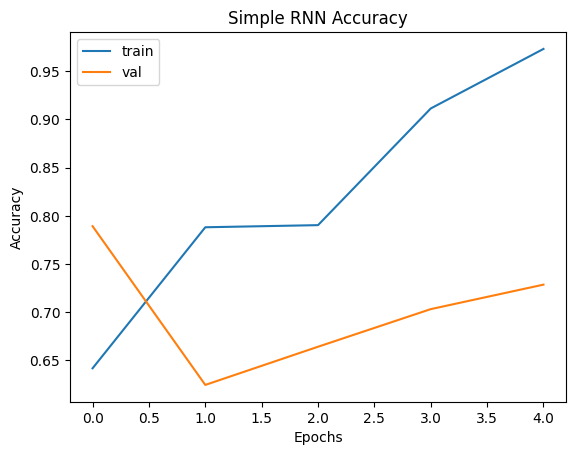

In [7]:
plt.plot(history_rnn.history['accuracy'], label='train')
plt.plot(history_rnn.history['val_accuracy'], label='val')
plt.title("Simple RNN Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

LSTM Model

In [8]:
model_lstm = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.LSTM(64),
    layers.Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 137ms/step - accuracy: 0.7784 - loss: 0.4570 - val_accuracy: 0.8624 - val_loss: 0.3361
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.8977 - loss: 0.2641 - val_accuracy: 0.8632 - val_loss: 0.3240
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 133ms/step - accuracy: 0.9281 - loss: 0.1891 - val_accuracy: 0.8650 - val_loss: 0.3345
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 123ms/step - accuracy: 0.9444 - loss: 0.1550 - val_accuracy: 0.8464 - val_loss: 0.3714
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 137ms/step - accuracy: 0.9464 - loss: 0.1466 - val_accuracy: 0.8614 - val_loss: 0.4133


In [9]:
test_loss_lstm, test_acc_lstm = model_lstm.evaluate(x_test, y_test)
print("LSTM Test Accuracy:", test_acc_lstm)

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8580 - loss: 0.4294
LSTM Test Accuracy: 0.8579599857330322


GRU Model

In [10]:
model_gru = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.GRU(64),
    layers.Dense(1, activation='sigmoid')
])

model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history_gru = model_gru.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 154ms/step - accuracy: 0.7572 - loss: 0.4839 - val_accuracy: 0.7962 - val_loss: 0.4429
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.8928 - loss: 0.2656 - val_accuracy: 0.8732 - val_loss: 0.3173
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 141ms/step - accuracy: 0.9327 - loss: 0.1792 - val_accuracy: 0.8760 - val_loss: 0.3352
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.9606 - loss: 0.1121 - val_accuracy: 0.8706 - val_loss: 0.4061
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 149ms/step - accuracy: 0.9729 - loss: 0.0798 - val_accuracy: 0.8538 - val_loss: 0.4560


In [11]:
test_loss_gru, test_acc_gru = model_gru.evaluate(x_test, y_test)
print("GRU Test Accuracy:", test_acc_gru)

782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.8554 - loss: 0.4711
GRU Test Accuracy: 0.855400025844574


Accuracy Comparison

In [12]:
print("RNN Accuracy:", test_acc_rnn)
print("LSTM Accuracy:", test_acc_lstm)
print("GRU Accuracy:", test_acc_gru)

RNN Accuracy: 0.7324399948120117
LSTM Accuracy: 0.8579599857330322
GRU Accuracy: 0.855400025844574
